In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../Dataset/final_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (2392, 11)


,GPA,Absences,Engagement_Ratio,StudyTimeWeekly,Support_Index,ParentalEducation,ParentalSupport,Age,Ethnicity,Activity_Score,GradeClass
0,0.732299,0.241379,4.095948,0.992773,3,2,2,0.666667,0,1,2.0
1,0.760729,0.000000,771.270492,0.771270,1,1,1,1.000000,0,0,1.0
2,0.028151,0.896552,0.234769,0.210718,2,3,2,0.000000,2,0,4.0
3,0.513555,0.482759,1.037635,0.501965,3,3,3,0.666667,0,1,3.0
4,0.322015,0.586207,0.398225,0.233840,4,2,3,0.666667,0,0,4.0


In [9]:
from sklearn.model_selection import train_test_split

X = df.drop('GradeClass', axis=1)
y = df['GradeClass']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)
print("Features:", X.columns.tolist())

Train size: (1913, 10)
Test size: (479, 10)
Features: ['GPA', 'Absences', 'Engagement_Ratio', 'StudyTimeWeekly', 'Support_Index', 'ParentalEducation', 'ParentalSupport', 'Age', 'Ethnicity', 'Activity_Score']


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

print("=== Logistic Regression ===")
print("Accuracy:", round(accuracy_score(y_test, lr_pred), 4))
print(classification_report(y_test, lr_pred))

=== Logistic Regression ===
Accuracy: 0.737
              precision    recall  f1-score   support

         0.0       0.25      0.05      0.08        21
         1.0       0.54      0.48      0.51        54
         2.0       0.52      0.71      0.60        78
         3.0       0.66      0.42      0.51        83
         4.0       0.88      0.97      0.92       243

    accuracy                           0.74       479
   macro avg       0.57      0.53      0.53       479
weighted avg       0.72      0.74      0.72       479



In [11]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print("=== Random Forest ===")
print("Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print(classification_report(y_test, rf_pred))

=== Random Forest ===
Accuracy: 0.9186
              precision    recall  f1-score   support

         0.0       1.00      0.43      0.60        21
         1.0       0.87      0.89      0.88        54
         2.0       0.91      0.94      0.92        78
         3.0       0.88      0.89      0.89        83
         4.0       0.94      0.97      0.96       243

    accuracy                           0.92       479
   macro avg       0.92      0.82      0.85       479
weighted avg       0.92      0.92      0.91       479



In [12]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss')
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("=== XGBoost ===")
print("Accuracy:", round(accuracy_score(y_test, xgb_pred), 4))
print(classification_report(y_test, xgb_pred))

=== XGBoost ===
Accuracy: 0.9144
              precision    recall  f1-score   support

         0.0       1.00      0.48      0.65        21
         1.0       0.88      0.83      0.86        54
         2.0       0.88      0.95      0.91        78
         3.0       0.89      0.88      0.88        83
         4.0       0.94      0.97      0.95       243

    accuracy                           0.91       479
   macro avg       0.92      0.82      0.85       479
weighted avg       0.92      0.91      0.91       479



                 Model  Accuracy
0  Logistic Regression  0.736952
1        Random Forest  0.918580
2              XGBoost  0.914405


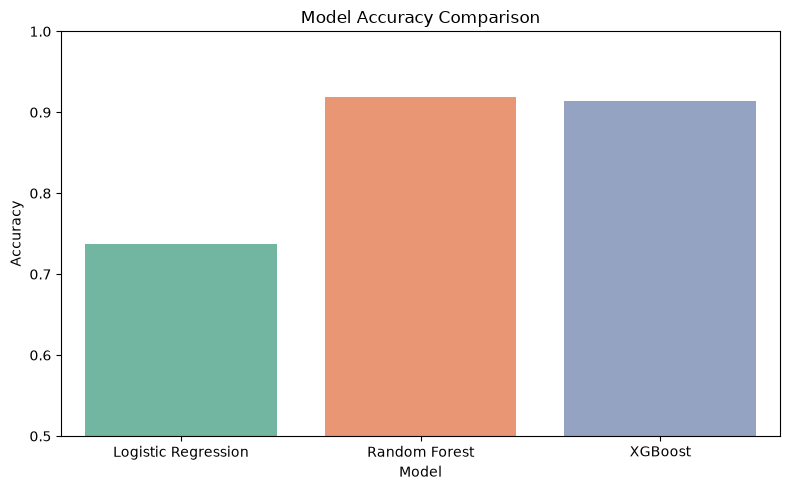

✅ Comparison chart saved


In [13]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost'],
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ]
})

print(results)

plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='Accuracy', data=results, palette='Set2')
plt.title('Model Accuracy Comparison')
plt.ylim(0.5, 1.0)
plt.tight_layout()
plt.savefig('../Documentation/model_comparison.png')
plt.show()
print("✅ Comparison chart saved")

In [14]:
joblib.dump(lr, '../Model/logistic_regression.pkl')
joblib.dump(rf, '../Model/random_forest.pkl')
joblib.dump(xgb, '../Model/xgboost.pkl')
joblib.dump(X.columns.tolist(), '../Model/feature_names.pkl')

print("✅ All models saved!")
print("Features saved:", X.columns.tolist())

✅ All models saved!
Features saved: ['GPA', 'Absences', 'Engagement_Ratio', 'StudyTimeWeekly', 'Support_Index', 'ParentalEducation', 'ParentalSupport', 'Age', 'Ethnicity', 'Activity_Score']
